# Churn Prediction

## Imports

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

## Dataset Info

In [69]:
CSV_FILE = "Churn_Modelling.csv"
TARGET = "Exited"
UNNECESSARY_FEATURES = ["RowNumber", "CustomerId", "Surname"]
NOMINAL_FEATURES = ["Surname", "Geography", "Gender"]
RANDOM_STATE = 42

data_frame = pd.read_csv(CSV_FILE)
data_frame

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## No Values Missing

In [70]:
data_frame.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Encode Nominal Features

In [71]:
label_encoder = LabelEncoder()
for nominal_feature in NOMINAL_FEATURES:
    if nominal_feature in UNNECESSARY_FEATURES:
        pass
        
    else:
        current_feature_values = data_frame[nominal_feature]
        label_encoder.fit(current_feature_values)
        data_frame[nominal_feature] = label_encoder.transform(current_feature_values)

## Feature Removal

In [72]:
data_frame = data_frame.drop(columns=UNNECESSARY_FEATURES)
data_frame.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


## Show Unscaled Features

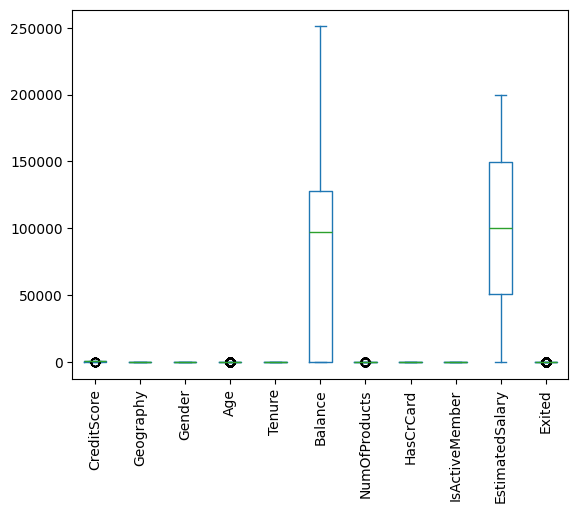

In [73]:
data_frame.plot(kind="box")
plt.xticks(rotation=90)
plt.show()

## Define Features

In [74]:
x = data_frame.drop(columns=[TARGET])
x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


## Define Target

In [75]:
y = data_frame[TARGET]
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

## Define Function for Testing Models

In [76]:
def test_model(model):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, train_size=0.8, random_state=RANDOM_STATE, stratify=y)
    model.fit(x_train, y_train)
    y_test_predicted = model.predict(x_test)
    
    print(classification_report(y_test, y_test_predicted))
    return model

## Test Decision Tree

In [77]:
test_model(DecisionTreeClassifier(random_state=RANDOM_STATE))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1593
           1       0.45      0.48      0.46       407

    accuracy                           0.78      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.78      0.78      0.78      2000



DecisionTreeClassifier(random_state=42)